In [1]:
import random
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from ortools.sat.python import cp_model

In [2]:
params = {
        "tps": 8,
        "final_product": "JT12",
        "amount": 2,
        "horizon": 50,
        "holding_cost": {
            "JT1": 1, "JT2": 1,     # 원재료
            "JT4": 3, "JT5": 3,     # 1차 가공
            "JT9": 6,               # 2차 가공
            "JT12": 10,             # 최종 제품
        }}

boms = {
    "JT4": {
        "JT1": 2,
        "JT2": 1},
    "JT5": {
        "JT1": 1},
    "JT9": {
        "JT4": 1,
        "JT5": 1},
    "JT12": {
        "JT9": 1,
        "JT5": 1}}

factories = {
    "Fc1": {
        "JT1": {"lots": [5, 10], "time": 1},
        "JT2": {"lots": [5, 10], "time": 1}},

    "Fc2": {
        "JT4": {"lots": [2], "time": 2},
        "JT5": {"lots": [2], "time": 2}},

    "Fc3": {
        "JT9": {"lots": [1], "time": 3}},

    "Fc4": {
        "JT12": {"lots": [1], "time": 4}}}

fcs = list(factories)
random.seed(4233)
deliveries = {fc1: {fc2 : random.randint(3, 8) if fc1 != fc2 else 1 for fc2 in fcs} for fc1 in fcs}

In [3]:
class Process:
    def __init__(self): pass
class Deliver:
    def __init__(self): pass

In [4]:
process, deliver, ini_set = Process(), Deliver(), {}
for fc in factories.keys():
    ini_set[fc] = {}
    for jt in factories[fc].keys():
        ini_set[fc][jt] = factories[fc][jt]["lots"]
        setattr(process, f"{fc}{jt}", factories[fc][jt]["time"])
for fc1 in deliveries.keys():
    for fc2 in deliveries[fc1].keys():
        setattr(deliver, f"{fc1}{fc2}", deliveries[fc1][fc2])

In [5]:
horizon = params["horizon"]
job_interval_horizon = {fc: {jt: horizon // getattr(process, f"{fc}{jt}") + 1 for jt in ini_set[fc].keys()} for fc in ini_set.keys()}

In [6]:
md = cp_model.CpModel()

fc_wip_t, fc_deliver_to = {}, {}
for fc in ini_set.keys():
    fc_wip_t[fc] = {}
    for jt in ini_set[fc].keys():
        fc_wip_t[fc][jt] = {t: md.new_int_var(0, horizon, f"{fc}_{jt}_{t}") if t else 0 for t in range(horizon)}
        for fc_prime in set([fc_prime for fc_prime in ini_set.keys() for jt_prime in ini_set[fc_prime] if jt_prime in boms and jt in boms[jt_prime]]):
            if fc not in fc_deliver_to: fc_deliver_to[fc] = {}
            if fc_prime not in fc_deliver_to[fc]: fc_deliver_to[fc][fc_prime] = []
            fc_deliver_to[fc][fc_prime].append(jt)

delivered, ingredients = {}, {}
for fc1 in fc_deliver_to.keys():
    for fc2 in fc_deliver_to[fc1].keys():
        if fc2 not in delivered: delivered[fc2] = {}
        if fc2 not in ingredients: ingredients[fc2] = set()
        delivered[fc2][fc1] = {}
        for ingredient in fc_deliver_to[fc1][fc2]:
            delivered[fc2][fc1][ingredient] = {t: md.new_int_var(0, horizon, f"{fc2}_{ingredient}_{t}_delivered_from_{fc1}") for t in range(1, horizon)}
            ingredients[fc2].add(ingredient)
for fc in ingredients.keys():
    for ingredient in ingredients[fc]:
        if ingredient not in fc_wip_t[fc]:
            fc_wip_t[fc][ingredient] = {t: md.new_int_var(0, horizon, f"{fc}_{ingredient}_{t}") if t else 0 for t in range(horizon)}

sem, intervals = {}, {} # Start End Make => Interval
produced, consumed = {}, {}
se_event = {}
for fc in ini_set.keys():
    sem[fc] = {}
    intervals[fc] = {}
    produced[fc] = {}
    consumed[fc] = {}
    se_event[fc] = {}
    for jt in ini_set[fc].keys():
        sem[fc][jt] = {}
        intervals[fc][jt] = {}
        produced[fc][jt] = {t: md.new_bool_var(f"{fc}_{jt}_{t}_produced") for t in range(1, horizon)}
        if jt in boms:
            consumed[fc][jt] = {ingredient: {t: md.new_int_var(0, boms[jt][ingredient], f"{fc}_{ingredient}_{t}_consumed") for t in range(1, horizon)} for ingredient in boms[jt].keys()}

        se_event[fc][jt] = {}
        for k in range(job_interval_horizon[fc][jt]):
            se_event[fc][jt][k] = {}
            sem[fc][jt][k] = [md.new_int_var(1, horizon - 1, f"{fc}_{jt}_{k}_st"), md.new_int_var(1, horizon - 1, f"{fc}_{jt}_{k}_ed"), md.new_bool_var(f"{fc}_{jt}_{k}_mk")]
            intervals[fc][jt][k] = md.new_optional_interval_var(sem[fc][jt][k][0], getattr(process, f"{fc}{jt}"), sem[fc][jt][k][1], sem[fc][jt][k][2], f"{fc}_{jt}_{k}_make")

            if k:
                md.add(sem[fc][jt][k - 1][2] >= sem[fc][jt][k][2])
                md.add(sem[fc][jt][k - 1][1] <= sem[fc][jt][k][0])

            for t in range(1, horizon):
                se_event[fc][jt][k][t] = [md.new_bool_var(f"{fc}{jt}{k}_{when}_{t}") for when in ("start", "end","real_start","real_end")]
                md.add(sem[fc][jt][k][0] == t).only_enforce_if(se_event[fc][jt][k][t][0])
                md.add(sem[fc][jt][k][0] != t).only_enforce_if(se_event[fc][jt][k][t][0].Not())

                md.add(sem[fc][jt][k][1] == t).only_enforce_if(se_event[fc][jt][k][t][1])
                md.add(sem[fc][jt][k][1] != t).only_enforce_if(se_event[fc][jt][k][t][1].Not())

                md.add_min_equality(se_event[fc][jt][k][t][2], [se_event[fc][jt][k][t][0], sem[fc][jt][k][2]])
                md.add_min_equality(se_event[fc][jt][k][t][3], [se_event[fc][jt][k][t][1], sem[fc][jt][k][2]])

        md.add_no_overlap(intervals[fc][jt].values())

        if jt in boms:
            for ingredient in boms[jt].keys():
                for t in range(1, horizon):
                    md.add(consumed[fc][jt][ingredient][t] == boms[jt][ingredient] * sum(se_event[fc][jt][k][t][2] for k in range(job_interval_horizon[fc][jt])))

        for t in range(1, horizon):
            md.add(produced[fc][jt][t] == 1 * sum(se_event[fc][jt][k][t][3] for k in range(job_interval_horizon[fc][jt])))

    if fc in ingredients:
        for ingredient in ingredients[fc]:
            use_this_ingredient_jt = [jt for jt in ini_set[fc].keys() if jt in boms and ingredient in boms[jt]]
            for t in range(1, horizon):
                md.add(fc_wip_t[fc][ingredient][t - 1] + sum(delivered[fc][fc1][ingredient][t] for fc1 in delivered[fc].keys() if ingredient in delivered[fc][fc1]) >= sum(boms[jt][ingredient] * sum(se_event[fc][jt][k][t][2] for k in range(job_interval_horizon[fc][jt])) for jt in use_this_ingredient_jt))

delivering = {}
for fc in fc_deliver_to.keys():
    delivering[fc] = {}
    for jt in ini_set[fc].keys():
        delivering[fc][jt] = {}
        use_ingredient_fc, lot_units = [fc2 for fc2 in fc_deliver_to[fc] if jt in fc_deliver_to[fc][fc2]], ini_set[fc][jt]
        for t in range(1, horizon):
            delivering[fc][jt][t] = {fc_prime: {lot_unit: md.new_int_var(0, horizon // 10, f"{fc}_{jt}_{t}_deliver_to_{fc_prime}_{lot_unit}") for lot_unit in lot_units} for fc_prime in use_ingredient_fc}
            md.add(fc_wip_t[fc][jt][t - 1] + produced[fc][jt][t] - sum(consumed[fc][jt_prime][jt][t] for jt_prime in ini_set[fc].keys() if jt_prime in boms and jt in boms[jt_prime]) >= sum(delivering[fc][jt][t][fc_prime][lot_unit] * lot_unit for fc_prime in use_ingredient_fc for lot_unit in lot_units))

        for fc_prime in use_ingredient_fc:
            deliver_time = getattr(deliver, f"{fc}{fc_prime}")
            for t in range(1, horizon):
                if t + deliver_time < horizon:
                    md.add(sum(delivering[fc][jt][t][fc_prime][lot_unit] * lot_unit for lot_unit in lot_units) == delivered[fc_prime][fc][jt][t + deliver_time])
                else:
                    md.add(sum(delivering[fc][jt][t][fc_prime][lot_unit] * lot_unit for lot_unit in lot_units) == 0)
            for t in range(1, min(horizon, deliver_time + 1)):
                md.add(delivered[fc_prime][fc][jt][t] == 0)

fcs, tps = list(ini_set.keys()), params["tps"]
arcs = [(f, g) for f in fcs for g in fcs if f != g]
truck_move = {arc: {t: md.new_int_var(0, tps, f"truck_{arc[0]}_to_{arc[1]}_{t}") for t in range(1, horizon)} for arc in arcs} # t에 f -> g 출발하는 트럭 수 (빈 차 이동 포함)
truck_idle = {f: {t: md.new_int_var(0, tps, f"truck_idle_{f}_{t}") for t in range(horizon)} for f in fcs} # t 시점 f에 대기 중인 트럭 수
truck_used = md.new_int_var(0, tps, "truck_used")
md.add(sum(truck_idle[f][0] for f in fcs) == truck_used) # 초기 배치된 트럭 수 = 투입 트럭 수

for f, g in arcs:
    for t in range(1, horizon):
        if t + getattr(deliver, f"{f}{g}") >= horizon:
            md.add(truck_move[(f, g)][t] == 0)
for f in fcs:
    for t in range(1, horizon):
        arrive = sum(truck_move[(g, f)][t - getattr(deliver, f"{g}{f}")] for g in fcs if g != f and t - getattr(deliver, f"{g}{f}") >= 1)
        depart = sum(truck_move[(f, g)][t] for g in fcs if g != f)
        md.add(truck_idle[f][t] == truck_idle[f][t - 1] + arrive - depart)

for fc in fc_deliver_to.keys():
    for fc_prime in fc_deliver_to[fc].keys():
        if fc == fc_prime: continue
        for t in range(1, horizon):
            load = sum(delivering[fc][jt][t][fc_prime][lot_unit] * lot_unit for jt in fc_deliver_to[fc][fc_prime] for lot_unit in ini_set[fc][jt])
            md.add(load <= horizon * truck_move[(fc, fc_prime)][t]) # 적재 무제한 => 싣는 게 있으면 트럭 1대 이상 출발

truck_travel = md.new_int_var(0, tps * horizon, "truck_travel")
md.add(truck_travel == sum(truck_move[(f, g)][t] * getattr(deliver, f"{f}{g}") for f, g in arcs for t in range(1, horizon)))

for fc in fc_wip_t.keys():
    for wip in fc_wip_t[fc].keys():
        for t in range(1, horizon):
            md.add(fc_wip_t[fc][wip][t] == fc_wip_t[fc][wip][t - 1] + (produced[fc][wip][t] if wip in produced[fc] else 0) + (sum(delivered[fc][fc_prime][wip][t] for fc_prime in delivered[fc] if wip in delivered[fc][fc_prime]) if fc in delivered else 0) - sum(consumed[fc][jt_prime][wip][t] for jt_prime in consumed[fc] if wip in consumed[fc][jt_prime]) - (sum(delivering[fc][wip][t][fc_prime][lot_unit] * lot_unit for lot_unit in ini_set[fc][wip] for fc_prime in fc_deliver_to[fc].keys() if wip in fc_deliver_to[fc][fc_prime]) if fc in delivering and wip in delivering[fc] else 0))


every_final_product_max_set = {}
for fc in ini_set.keys():
    if params["final_product"] in ini_set[fc]:
        every_final_product_max_set[fc] = md.new_int_var(0, params["amount"], f"{fc}_FP")
        md.add_max_equality(every_final_product_max_set[fc], fc_wip_t[fc][params["final_product"]].values())
md.add(sum(every_final_product_max_set.values()) >= params["amount"])

every_fc_num_job = {}
for fc in ini_set.keys():
    every_fc_num_job[fc] = md.new_int_var(0, max(job_interval_horizon[fc].values()) * len(ini_set[fc]), f"{fc}_total_job_num")
    md.add(every_fc_num_job[fc] == sum(sem[fc][jt][k][2] for jt in ini_set[fc] for k in range(job_interval_horizon[fc][jt])))

total_makespan = md.new_int_var(0, horizon, "total_makespan")
md.add_max_equality(total_makespan, [sem[fc][jt][k][1] for fc in sem.keys() for jt in sem[fc].keys() for k in range(job_interval_horizon[fc][jt])])

hold_cost = params["holding_cost"]
before_makespan = {t: md.new_bool_var(f"{t}_before_makespan") for t in range(1, horizon)}
for t in range(1, horizon):
    md.add(total_makespan >= t + 1).only_enforce_if(before_makespan[t])
    md.add(total_makespan <= t).only_enforce_if(before_makespan[t].Not())
held, holding = {}, {}
for fc in fc_wip_t.keys():
    held[fc], holding[fc] = {}, {}
    for wip in fc_wip_t[fc].keys():
        held[fc][wip] = {t: md.new_int_var(0, horizon, f"{fc}_{wip}_{t}_held") for t in range(1, horizon)}
        for t in range(1, horizon):
            md.add(held[fc][wip][t] >= fc_wip_t[fc][wip][t] - horizon * (1 - before_makespan[t]))
        holding[fc][wip] = hold_cost.get(wip, 0) * sum(held[fc][wip].values())
hold_ub = sum(hold_cost.get(wip, 0) * horizon * (horizon - 1) for fc in fc_wip_t for wip in fc_wip_t[fc])

for fc in fc_deliver_to.keys():
    for fc_prime in fc_deliver_to[fc].keys():
        deliver_time, route = getattr(deliver, f"{fc}{fc_prime}"), f"{fc}→{fc_prime}"
        held[route], holding[route] = {}, {}
        for jt in fc_deliver_to[fc][fc_prime]:
            held[route][jt] = {t: md.new_int_var(0, horizon * deliver_time, f"{route}_{jt}_{t}_held") for t in range(1, horizon)}
            for t in range(1, horizon):
                in_transit = sum(delivering[fc][jt][s][fc_prime][lot_unit] * lot_unit for s in range(max(1, t - deliver_time + 1), t + 1) for lot_unit in ini_set[fc][jt])
                md.add(held[route][jt][t] >= in_transit - horizon * deliver_time * (1 - before_makespan[t]))
            holding[route][jt] = hold_cost.get(jt, 0) * sum(held[route][jt].values())
            hold_ub += hold_cost.get(jt, 0) * horizon * deliver_time * (horizon - 1)
total_holding = md.new_int_var(0, hold_ub, "total_holding_cost")
md.add(total_holding == sum(holding[fc][wip] for fc in holding for wip in holding[fc]))

total_job = sum(every_fc_num_job.values())
job_ub = sum(job_interval_horizon[fc][jt] for fc in ini_set for jt in ini_set[fc])
w_used = tps * horizon + 1
w_job = tps * w_used + tps * horizon + 1
w_hold = job_ub * w_job + w_job
w_makespan = hold_ub * w_hold + w_hold
md.minimize(w_makespan * total_makespan + w_hold * total_holding + w_job * total_job + w_used * truck_used + truck_travel)
solver = cp_model.CpSolver()
status = solver.Solve(md)

In [7]:
if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    total_makespan = round(solver.value(total_makespan))
    print("Status :", solver.status_name(status))
    print("Total Makespan :", total_makespan)
    print("Holding Cost :", solver.value(total_holding))
    for fc in holding.keys():
        for wip in holding[fc].keys():
            if cost := solver.value(holding[fc][wip]):
                print(f"    {fc} {wip} : {cost} (= {hold_cost.get(wip, 0)} x {sum(solver.value(v) for v in held[fc][wip].values())} unit*time)")
    print("Total Job :", solver.value(total_job))
    print("Truck Used :", solver.value(truck_used), "/", tps)
    print("Truck Travel :", solver.value(truck_travel), "\n")

    jobs = [(fc, jt, k, solver.value(sem[fc][jt][k][0]), solver.value(sem[fc][jt][k][1])) for fc in sem.keys() for jt in sem[fc].keys() for k in range(job_interval_horizon[fc][jt]) if solver.value(sem[fc][jt][k][2])]

    trucks = [{"home": f, "loc": f, "free": 0, "moves": []} for f in fcs for _ in range(solver.value(truck_idle[f][0]))]
    departures = sorted((t, f, g, solver.value(truck_move[(f, g)][t])) for f, g in arcs for t in range(1, horizon) if solver.value(truck_move[(f, g)][t]))
    for t, f, g, num in departures:
        cargo = {}
        if f in fc_deliver_to and g in fc_deliver_to[f]:
            cargo = {jt: amount for jt in fc_deliver_to[f][g] if (amount := sum(solver.value(delivering[f][jt][t][g][lot_unit]) * lot_unit for lot_unit in ini_set[f][jt]))}
        ready = [truck for truck in trucks if truck["loc"] == f and truck["free"] <= t][:num]
        assert len(ready) == num, f"truck flow broken at {f} t={t}"
        for i, truck in enumerate(ready):
            arrive = t + getattr(deliver, f"{f}{g}")
            truck["moves"].append((f, g, t, arrive, cargo if i == 0 else {}))
            truck["loc"], truck["free"] = g, arrive
    for i, truck in enumerate(trucks):
        print(f"tr{i + 1} (start {truck['home']})")
        for f, g, t, arrive, cargo in truck["moves"]:
            print(f"    {f} -> {g} | {t} ~ {arrive} ({arrive - t}) | {cargo if cargo else 'empty'}")
else:
    print('X')

Status : OPTIMAL
Total Makespan : 40
Holding Cost : 518
    Fc1 JT1 : 35 (= 1 x 35 unit*time)
    Fc1 JT2 : 10 (= 1 x 10 unit*time)
    Fc2 JT4 : 39 (= 3 x 13 unit*time)
    Fc2 JT5 : 12 (= 3 x 4 unit*time)
    Fc2 JT1 : 54 (= 1 x 54 unit*time)
    Fc2 JT2 : 73 (= 1 x 73 unit*time)
    Fc3 JT5 : 12 (= 3 x 4 unit*time)
    Fc3 JT4 : 12 (= 3 x 4 unit*time)
    Fc4 JT12 : 40 (= 10 x 4 unit*time)
    Fc4 JT5 : 12 (= 3 x 4 unit*time)
    Fc1→Fc2 JT1 : 30 (= 1 x 30 unit*time)
    Fc1→Fc2 JT2 : 15 (= 1 x 15 unit*time)
    Fc2→Fc3 JT4 : 42 (= 3 x 14 unit*time)
    Fc2→Fc3 JT5 : 42 (= 3 x 14 unit*time)
    Fc2→Fc4 JT5 : 18 (= 3 x 6 unit*time)
    Fc3→Fc4 JT9 : 72 (= 6 x 12 unit*time)
Total Job : 26
Truck Used : 3 / 8
Truck Travel : 28 

tr1 (start Fc1)
    Fc1 -> Fc2 | 9 ~ 12 (3) | {'JT1': 5, 'JT2': 5}
    Fc2 -> Fc3 | 16 ~ 23 (7) | {'JT4': 2, 'JT5': 2}
    Fc3 -> Fc4 | 26 ~ 32 (6) | {'JT9': 1}
tr2 (start Fc1)
    Fc1 -> Fc2 | 11 ~ 14 (3) | {'JT1': 5}
    Fc2 -> Fc4 | 29 ~ 32 (3) | {'JT5': 2}
t

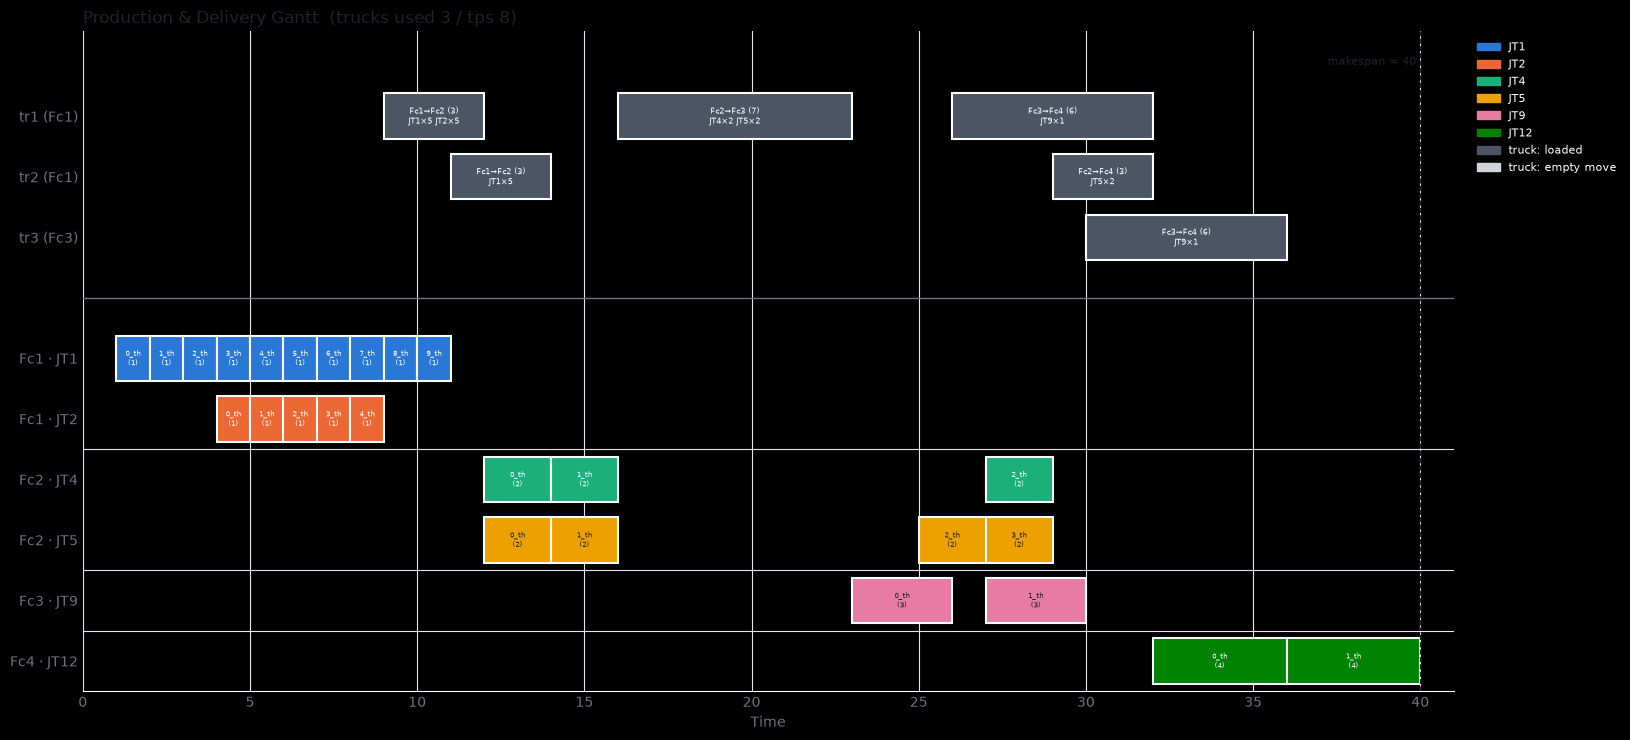

In [8]:
if status in (cp_model.OPTIMAL, cp_model.FEASIBLE):
    palette = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
    INK, MUTED, GRID, GO, RETURN = "#1f2328", "#6b7280", "#e5e7eb", "#4b5563", "#d1d5db"

    jt_order = list(dict.fromkeys(jt for fc in ini_set for jt in ini_set[fc]))
    jt_color = {jt: palette[i % len(palette)] for i, jt in enumerate(jt_order)}
    text_on = lambda hex_color: INK if sum(int(hex_color[i:i + 2], 16) * w for i, w in ((1, 0.299), (3, 0.587), (5, 0.114))) > 140 else "white"
    n_truck = len(trucks)

    y_of = {f"tr{i + 1} ({truck['home']})": i for i, truck in enumerate(trucks)}
    truck_rows = list(y_of.keys())
    fc_first_row = {}
    for fc in ini_set:
        fc_first_row[fc] = len(y_of) + 1
        for jt in ini_set[fc]:
            y_of[f"{fc} · {jt}"] = len(y_of) + 1
    x_max = max([total_makespan] + [move[3] for truck in trucks for move in truck["moves"]]) + 1

    _, ax = plt.subplots(figsize=(max(14, x_max * 0.4), 0.6 * (len(y_of) + 1) + 1.5))
    h = 0.75

    for fc, jt, k, st, ed in jobs:
        y = y_of[f"{fc} · {jt}"]
        ax.barh(y, ed - st, left=st, height=h, color=jt_color[jt], edgecolor="white", linewidth=1.5)
        ax.text((st + ed) / 2, y, f"{k}_th\n({ed - st})", ha="center", va="center", fontsize=5, color=text_on(jt_color[jt]))

    for row, truck in zip(truck_rows, trucks):
        y = y_of[row]
        for fc_from, fc_to, depart, arrive, cargo in truck["moves"]:
            ax.barh(y, arrive - depart, left=depart, height=h, color=GO if cargo else RETURN, edgecolor="white", linewidth=1.5)
            label = f"{fc_from}→{fc_to} ({arrive - depart})"
            label += "\n" + " ".join(f"{jt}×{n}" for jt, n in cargo.items()) if cargo else "\nempty"
            ax.text((depart + arrive) / 2, y, label, ha="center", va="center", fontsize=6, color="white" if cargo else INK)

    ax.axvline(total_makespan, color=INK, linestyle="--", linewidth=1)
    ax.text(total_makespan, -0.9, f"makespan = {total_makespan} ", ha="right", va="center", fontsize=8, color=INK)
    for fc in list(fc_first_row)[1:]:
        ax.axhline(fc_first_row[fc] - 0.5, color=GRID, linewidth=0.8)
    ax.axhline(n_truck, color=MUTED, linewidth=1)

    ax.set_yticks(list(y_of.values()), list(y_of.keys()))
    ax.set_ylim(len(y_of) + 0.5, -1.4)
    ax.set_xlim(0, x_max)
    ax.set_xlabel("Time", color=MUTED)
    ax.set_title(f"Production & Delivery Gantt  (trucks used {n_truck} / tps {tps})", loc="left", color=INK)
    ax.grid(axis="x", color=GRID, linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.tick_params(colors=MUTED, length=0)

    handles = [Patch(color=jt_color[jt], label=jt) for jt in jt_order]
    handles += [Patch(color=GO, label="truck: loaded"), Patch(color=RETURN, label="truck: empty move")]
    ax.legend(handles=handles, loc="upper left", bbox_to_anchor=(1.01, 1), frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()